# Import Libraries

In [3]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt


# Load Dataset

In [4]:
df = pd.read_csv("netflix_titles.csv")

# Preview Data

In [5]:
print("First 5 rows:")
print(df.head())

First 5 rows:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24

# Check missing values

In [6]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


# Handle missing values in description

In [8]:
df['description'] = df['description'].fillna("")

#  Apply Sentiment Analysis (Polarity Score)

In [9]:
df['sentiment_score'] = df['description'].apply(lambda x: TextBlob(x).sentiment.polarity)


# Convert Score to Labels (Positive / Negative / Neutral)

In [11]:
def get_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['sentiment_score'].apply(get_sentiment)

# Show Sample Results

In [12]:
print("\nSample Sentiment Results:")
print(df[['title', 'description', 'sentiment']].head())


Sample Sentiment Results:
                   title                                        description  \
0   Dick Johnson Is Dead  As her father nears the end of his life, filmm...   
1          Blood & Water  After crossing paths at a party, a Cape Town t...   
2              Ganglands  To protect his family from a powerful drug lor...   
3  Jailbirds New Orleans  Feuds, flirtations and toilet talk go down amo...   
4           Kota Factory  In a city of coaching centers known to train I...   

  sentiment  
0  Positive  
1   Neutral  
2  Negative  
3  Negative  
4   Neutral  


# Count Sentiment Categories

In [13]:
sentiment_counts = df['sentiment'].value_counts()
print("\nSentiment Distribution:")
print(sentiment_counts)


Sentiment Distribution:
sentiment
Positive    4547
Negative    2662
Neutral     1598
Name: count, dtype: int64


# Bar Chart (Sentiment Distribution)

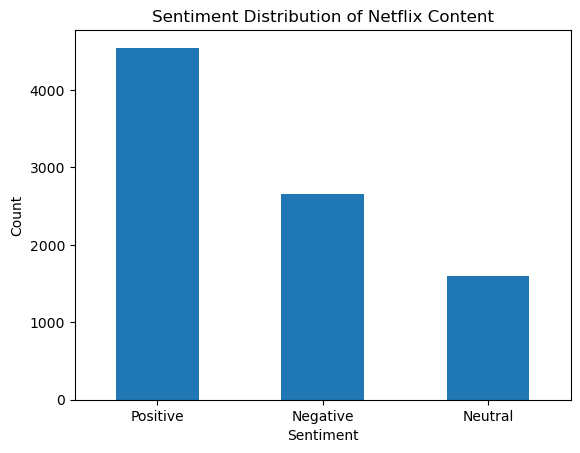

In [14]:
plt.figure()
sentiment_counts.plot(kind='bar')
plt.title("Sentiment Distribution of Netflix Content")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Histogram (Sentiment Score)

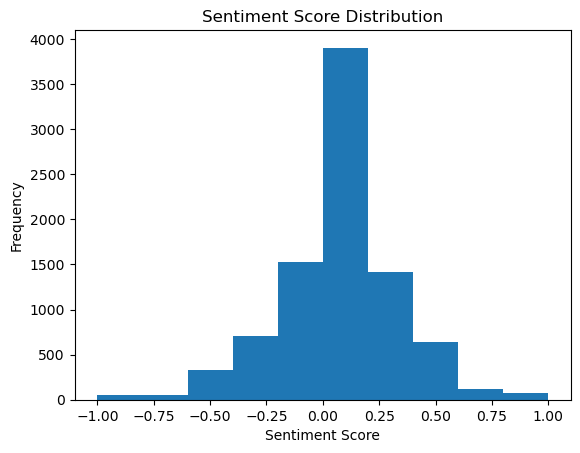

In [16]:
plt.figure()
df['sentiment_score'].plot(kind='hist')
plt.title("Sentiment Score Distribution")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()

# Save Results to CSV 

In [17]:
df.to_csv("netflix_sentiment_output.csv", index=False)

print("\nAnalysis complete! Output file saved as 'netflix_sentiment_output.csv'")


Analysis complete! Output file saved as 'netflix_sentiment_output.csv'


# Findings:

•	Majority of Netflix content descriptions are Neutral or Positive

•	Very few descriptions are Negative

•	This shows Netflix content is generally presented in a positive tone


# Use Case:

•	Helps understand audience perception

•	Useful for recommendation systems

•	Can support marketing strategies

